## <font color='blue'>Previsao de Preço de Ativos</font>

In [ ]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
%pip install -q -U watermark

In [ ]:
# Instala o pacote yfinance para obter dados financeiros do Yahoo Finance.
#https://finance.yahoo.com/
#https://pypi.org/project/yfinance/
%pip install -q yfinance

In [3]:
# Analysis and Visualization
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelagem
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [4]:
%reload_ext watermark
%watermark -a "Ivair Bezerra" --iversions

Author: Ivair Bezerra

yfinance  : 0.2.57
sklearn   : 1.6.0
pandas    : 2.2.3
matplotlib: 3.10.0
numpy     : 2.1.1



## Extração dos Dadoa via API

In [5]:
# Coleta de dados do índice S&P 500

#"^GSPC"**: é o símbolo (ticker) que representa o índice S&P 500 no Yahoo Finance. 
# O S&P 500 é um índice que reflete a performance de 500 das maiores empresas listadas 
# nas bolsas de valores dos Estados Unidos, sendo amplamente considerado como um dos melhores 
# indicadores da performance do mercado de ações.

#https://finance.yahoo.com/quote/%5EGSPC/

#Você pode customizar o projeto com outros Tickers:
#https://stockanalysis.com/list/nasdaq-stocks/

df = yf.Ticker("^GSPC")
type(df)

yfinance.ticker.Ticker

In [9]:
# Obtém o histórico completo de dados do índice S&P 500
df_hist = df.history(period="max")


## Analise Exploratoria

In [11]:
# Shape
df_hist.shape

(24576, 7)

In [12]:
df_hist.head(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [13]:
df_hist.tail(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-10-27 00:00:00-04:00,6845.459961,6877.279785,6843.939941,6875.160156,5290650000,0.0,0.0
2025-10-28 00:00:00-04:00,6897.740234,6911.299805,6870.729980,6890.890137,5695930000,0.0,0.0
2025-10-29 00:00:00-04:00,6910.950195,6920.339844,6851.910156,6890.589844,6280130000,0.0,0.0
2025-10-30 00:00:00-04:00,6860.500000,6880.750000,6820.689941,6822.339844,6052700000,0.0,0.0
2025-10-31 00:00:00-04:00,6879.169922,6879.169922,6814.259766,6840.200195,6398280000,0.0,0.0


In [16]:
# Indices de DataFrame
df_hist.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-10-20 00:00:00-04:00', '2025-10-21 00:00:00-04:00',
               '2025-10-22 00:00:00-04:00', '2025-10-23 00:00:00-04:00',
               '2025-10-24 00:00:00-04:00', '2025-10-27 00:00:00-04:00',
               '2025-10-28 00:00:00-04:00', '2025-10-29 00:00:00-04:00',
               '2025-10-30 00:00:00-04:00', '2025-10-31 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24576, freq=None)

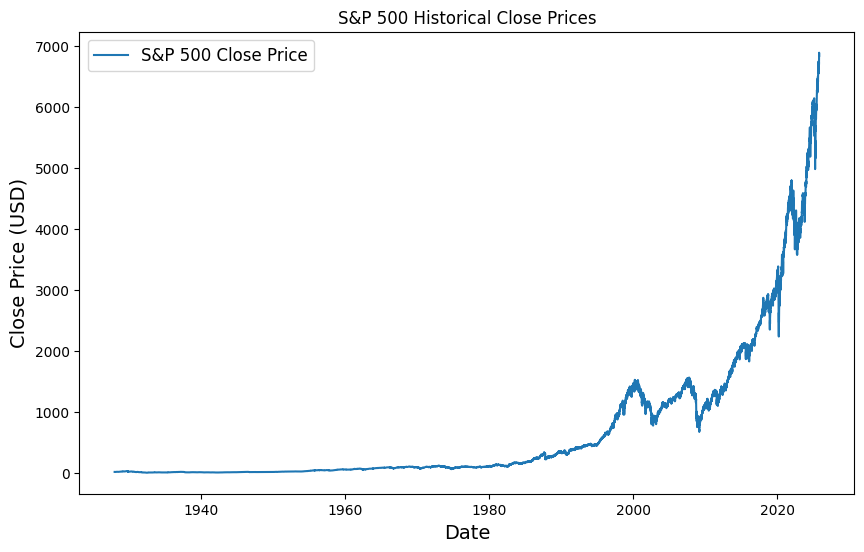

In [18]:
#Define o tamanho da figura do gráfico
plt.figure(figsize=(10,6))

#Cria o gráfico de linha para a coluna `Close`
plt.plot(df_hist.index, df_hist['Close'], label='S&P 500 Close Price')

#Adiciona um título ao gráfico
plt.title('S&P 500 Historical Close Prices')

#Adiciona rótulos aos eixos x e y
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price (USD)', fontsize=14)

#Mostra a legenda
# O parametro loc controla a posição da legenda no gráfico. Ex. `upper left`, `upper right`, `lower left`, `lower right`, `center`, etc.
plt.legend(loc='best', fontsize=12)

#Mostra o grafico
plt.show()

In [ ]:
# Deletar as colunas que nao serao usadas no modelo -- Engenheiro de IA decide quais colunas manter
del df_hist['Dividends']
del df_hist['Stock Splits']

In [20]:
df_hist.head()

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0


In [21]:
df_hist.describe()

,Open,High,Low,Close,Volume
count,24576.000000,24576.000000,24576.000000,24576.000000,2.457600e+04
mean,704.538487,708.604288,700.210490,704.687390,9.552270e+08
std,1191.220452,1197.558644,1184.373001,1191.442180,1.669042e+09
min,4.400000,4.400000,4.400000,4.400000,0.000000e+00
25%,24.877500,24.877500,24.877500,24.877500,1.580000e+06
50%,103.320000,104.180000,102.424999,103.320000,2.170000e+07
75%,1081.837463,1091.524994,1072.812469,1083.190002,1.130650e+09
max,6910.950195,6920.339844,6870.729980,6890.890137,1.145623e+10
